# 부동산·임대료 데이터 수집 및 정제

## 목적

창업 입지 평가를 위해 서울 25개 자치구별 부동산·임대료 관련 변수를 구축한다.

3개 상가유형을 모두 포함한다.

- 소규모 상가
- 중대형 상가
- 집합 상가

## 최종 산출물

최종 파일명은 `team1_rent.csv`로 저장한다.

최종 컬럼은 다음과 같다.

- `gu`: 서울 자치구
- `q`: 분기 코드, 예: 20224 = 2022년 4분기
- `store_type`: 상가유형
- `rent_index_q`: 분기별 임대가격지수
- `rent_growth_yoy`: 전년 동기 대비 임대가격지수 증가율
- `vacancy_rate`: 공실률
- `transaction_count_q`: 자치구·분기별 상업업무용 부동산 거래 건수
- `avg_transaction_price`: 자치구·분기별 평균 거래금액

## 분석 기간

집합상가 공실률 자료가 2022년 4분기 이후부터 확인되므로, 세 상가유형을 동일 기준으로 비교하기 위해 공통 분석 기간을 2023년 1분기부터 2025년 4분기까지로 설정한다.

### 출처

상가 거래 실거래가

- 상업업무용 부동산 매매 실거래가 자료 기술문서 : 공공데이터포털

소규모 상가

- 임대가격지수 : R-one
- 공실률 : R-one


중대형 상가 

- 임대가격지수: R-one
- 공실률: R-one


집합 상가

- 임대가격지수: R-one
- 공실률 : R-one

# 1. 기본 설정

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# 현재 노트북 파일과 CSV 파일들이 같은 폴더에 있다고 가정
DATA_DIR = Path(".")

SEOUL_GU = [
    "종로구", "중구", "용산구", "성동구", "광진구",
    "동대문구", "중랑구", "성북구", "강북구", "도봉구",
    "노원구", "은평구", "서대문구", "마포구", "양천구",
    "강서구", "구로구", "금천구", "영등포구", "동작구",
    "관악구", "서초구", "강남구", "송파구", "강동구"
]

STORE_TYPES = ["소규모 상가", "중대형 상가", "집합 상가"]

# 공통 분석 기간: 2023년 1분기 ~ 2025년 4분기
QUARTERS_COMMON = [
    f"{year}{q}"
    for year in range(2023, 2026)
    for q in range(1, 5)
]

print("분석 분기:", QUARTERS_COMMON)
print("분기 수:", len(QUARTERS_COMMON))
print("예상 최종 행 수:", len(SEOUL_GU) * len(QUARTERS_COMMON) * len(STORE_TYPES))

분석 분기: ['20231', '20232', '20233', '20234', '20241', '20242', '20243', '20244', '20251', '20252', '20253', '20254']
분기 수: 12
예상 최종 행 수: 900


# 2. 상권면 -> 자치구 매핑

데이터가 자치구가 아니라 강남, 도심, 논현역, 연신내 같은 상권명으로 나오기 때문에 이 상권명을 서울 25개 자치구로 바꾸어 주어야 한다.

In [2]:
market_to_gu = {
    # 도심권
    "광화문": "종로구",
    "남대문": "중구",
    "동대문": "중구",
    "명동": "중구",
    "방산시장": "중구",
    "북촌": "종로구",
    "서촌": "종로구",
    "시청": "중구",
    "을지로": "중구",
    "종로": "종로구",
    "충무로": "중구",

    # 강남권
    "강남대로": "강남구",
    "교대역": "서초구",
    "남부터미널": "서초구",
    "논현역": "강남구",
    "도산대로": "강남구",
    "신사역": "강남구",
    "압구정": "강남구",
    "청담": "강남구",
    "테헤란로": "강남구",
    "방배역/내방역": "서초구",
    "서래마을": "서초구",
    "양재말죽거리": "서초구",
    "양재역": "서초구",
    "학동/강남구청역": "강남구",
    "한티역": "강남구",

    # 영등포/신촌권
    "공덕역": "마포구",
    "당산역": "영등포구",
    "동교/연남": "마포구",
    "망원역": "마포구",
    "신촌/이대": "서대문구",
    "신촌": "서대문구",
    "영등포역": "영등포구",
    "홍대/합정": "마포구",
    "홍대합정": "마포구",
    "여의도": "영등포구",

    # 기타권
    "가락시장": "송파구",
    "건대입구": "광진구",
    "경희대": "동대문구",
    "군자": "광진구",
    "까치산역": "강서구",
    "노량진": "동작구",
    "독산/시흥": "금천구",
    "뚝섬": "성동구",
    "목동": "양천구",
    "미아사거리": "강북구",
    "불광역": "은평구",
    "사당": "동작구",
    "상계역": "노원구",
    "상봉역": "중랑구",
    "서울대입구역": "관악구",
    "성신여대": "성북구",
    "수유": "강북구",
    "숙명여대": "용산구",
    "신림역": "관악구",
    "약수역": "중구",
    "연신내": "은평구",
    "오류동역": "구로구",
    "왕십리": "성동구",
    "용산역": "용산구",
    "이태원": "용산구",
    "잠실/송파": "송파구",
    "잠실송파": "송파구",
    "잠실새내역": "송파구",
    "장안동": "동대문구",
    "천호": "강동구",
    "청량리": "동대문구",
    "혜화동": "종로구",
    "화곡": "강서구",

    # 혹시 파일에 다르게 나오는 이름 보정
    "구로디지털단지역": "구로구",
    "구로디지털공단역": "구로구",
    "구의역": "광진구",
    "낙성대": "관악구",
    "쌍문역": "도봉구",
    "노원역": "노원구",
    "명일역": "강동구",
}

# 서울 전체, 도심, 강남 같은 큰 권역명은 자치구가 아니므로 제외
EXCLUDE_MARKET_NAMES = ["서울", "도심", "강남", "영등포신촌", "기타"]

# 3. R-ONE CSV 공통 처리 함수

이 함수는 임대가격지수 파일과 공실률 파일을 모두 처리하기 위한 공통 함수임

In [3]:
def period_to_q(period):
    """
    예: '2022년 4분기' -> '20224'
    """
    year = str(period).split("년")[0].strip()
    quarter = str(period).split("년")[1].replace("분기", "").strip()
    return f"{year}{quarter}"


def store_type_from_name(path):
    """
    파일명에서 상가유형을 추출한다.
    예: 임대동향 지역별 임대가격지수(시계열)_소규모 상가.csv -> 소규모 상가
    """
    name = Path(path).name

    for store_type in STORE_TYPES:
        if store_type in name:
            return store_type

    raise ValueError(f"상가유형을 찾을 수 없음: {name}")


def read_rone_wide(path, value_name):
    """
    R-ONE에서 다운로드한 wide 형태의 CSV를 long 형태로 변환한다.

    value_name이 rent_index_q이면 임대가격지수 처리,
    value_name이 vacancy_rate이면 공실률 처리.
    """
    store_type = store_type_from_name(path)

    df = pd.read_csv(path, encoding="cp949")

    # 중간에 반복되는 헤더 행 제거
    df = df[df["No"] != "No"].copy()

    # 서울 지역만 사용
    df = df[df["지역"] == "서울"].copy()

    # 서울, 도심, 강남 같은 권역 단위는 제외
    df = df[~df["지역.2"].isin(EXCLUDE_MARKET_NAMES)].copy()

    # 상가유형 추가
    df["store_type"] = store_type

    # 상권명 -> 자치구 매핑
    df["gu"] = df["지역.2"].map(market_to_gu)

    # 매핑 안 된 상권 확인
    unmapped = sorted(df[df["gu"].isna()]["지역.2"].dropna().unique())

    if len(unmapped) > 0:
        print("매핑 안 된 상권:", Path(path).name, unmapped)

    # 분기 컬럼 찾기
    quarter_cols = [
        col for col in df.columns
        if "년" in str(col) and "분기" in str(col)
    ]

    # wide -> long 변환
    long = df.melt(
        id_vars=["지역", "지역.1", "지역.2", "store_type", "gu"],
        value_vars=quarter_cols,
        var_name="period",
        value_name=value_name
    )

    # 분기 코드 생성
    long["q"] = long["period"].apply(period_to_q)

    # 숫자형 변환
    long[value_name] = pd.to_numeric(long[value_name], errors="coerce")

    return long

# 4. 임대가격지수 처리

여기서는 3개 파일을 읽는다.

- 소규모 상가 임대가격지수
- 중대형 상가 임대가격지수
- 집합 상가 임대가격지수

그리고 `rent_index_q`, `rent_growth_yoy`를 만든다.

- `rent_index_q`: 분기별 임대가격지수
- `rent_growth_yoy`: 전년 동기 대비 임대가격지수 증가율

In [4]:
rent_files = sorted(DATA_DIR.glob("임대동향 지역별 임대가격지수(시계열)_*상가.csv"))

print("임대가격지수 파일 수:", len(rent_files))

for f in rent_files:
    print("-", f.name)

임대가격지수 파일 수: 3
- 임대동향 지역별 임대가격지수(시계열)_소규모 상가.csv
- 임대동향 지역별 임대가격지수(시계열)_중대형 상가.csv
- 임대동향 지역별 임대가격지수(시계열)_집합 상가.csv


In [5]:
rent_all = pd.concat(
    [read_rone_wide(f, "rent_index_q") for f in rent_files],
    ignore_index=True
)

rent_gu_q_all = (
    rent_all
    .dropna(subset=["gu"])
    .groupby(["gu", "q", "store_type"], as_index=False)["rent_index_q"]
    .mean()
    .sort_values(["gu", "store_type", "q"])
)

# 전년 동기 대비 증가율
# pct_change(4)는 4분기 전과 비교한다는 뜻
rent_gu_q_all["rent_growth_yoy"] = (
    rent_gu_q_all
    .groupby(["gu", "store_type"])["rent_index_q"]
    .pct_change(4, fill_method=None) * 100
)

# 공통 분석 기간만 남김: 2022년 4분기 ~ 2025년 4분기
rent_gu_q = rent_gu_q_all[
    (rent_gu_q_all["q"] >= QUARTERS_COMMON[0]) &
    (rent_gu_q_all["q"] <= QUARTERS_COMMON[-1])
].copy()

rent_gu_q.head()

,gu,q,store_type,rent_index_q,rent_growth_yoy
36,강남구,20231,소규모 상가,95.865714,1.454403
39,강남구,20232,소규모 상가,96.837143,2.253666
42,강남구,20233,소규모 상가,97.775714,3.051975
45,강남구,20234,소규모 상가,98.278571,3.610048
48,강남구,20241,소규모 상가,98.998571,3.267964


# 5. 공실률 처리

공실률도 상가유형별로 읽는다.

In [6]:
vacancy_files = sorted(DATA_DIR.glob("임대동향 지역별 공실률*상가.csv"))

print("공실률 파일 수:", len(vacancy_files))

for f in vacancy_files:
    print("-", f.name)

공실률 파일 수: 6
- 임대동향 지역별 공실률(2022년~)_소규모 상가.csv
- 임대동향 지역별 공실률(2022년~)_중대형 상가.csv
- 임대동향 지역별 공실률(2022년~)_집합 상가.csv
- 임대동향 지역별 공실률(2024년3분기~)_소규모 상가.csv
- 임대동향 지역별 공실률(2024년3분기~)_중대형 상가.csv
- 임대동향 지역별 공실률(2024년3분기~)_집합 상가.csv


혹시나 모르는 중복을 정리하기 위해, 평균으로 중복을 정리

In [7]:
vacancy_all = pd.concat(
    [read_rone_wide(f, "vacancy_rate") for f in vacancy_files],
    ignore_index=True
)

# 공통 분석 기간만 사용
vacancy_all = vacancy_all[
    (vacancy_all["q"] >= QUARTERS_COMMON[0]) &
    (vacancy_all["q"] <= QUARTERS_COMMON[-1])
].copy()

# 같은 자치구·분기·상가유형이 여러 파일에 중복으로 있으면 평균 처리
vacancy_gu_q = (
    vacancy_all
    .dropna(subset=["gu"])
    .groupby(["gu", "q", "store_type"], as_index=False)["vacancy_rate"]
    .mean()
)

vacancy_gu_q.head()

,gu,q,store_type,vacancy_rate
0,강남구,20231,소규모 상가,2.028571
1,강남구,20231,중대형 상가,8.625000
2,강남구,20231,집합 상가,5.300000
3,강남구,20232,소규모 상가,0.371429
4,강남구,20232,중대형 상가,8.875000


# 6. 상업업무용 부동산 매매 실거래가 집계

국토부 상업업무용 부동산 매매 실거래가 자료에는 소규모·중대형·집합상가 구분이 없어서 상가유형별 거래 건수와 평균 거래가를 직접 산출하기는 어렵다. 따라서 거래 관련 변수는 상가유형별 변수가 아니라 자치구·분기 단위의 공통 변수로 사용하였다.

In [8]:
def parse_deal_amount(value):
    """
    dealAmount 문자열을 숫자로 변환한다.
    API의 dealAmount는 보통 만원 단위이므로 원 단위로 바꾸기 위해 10000을 곱한다.
    """
    if pd.isna(value):
        return np.nan

    value = str(value).replace(",", "").strip()

    if value == "":
        return np.nan

    return int(value) * 10000


def make_q_from_trade(row):
    """
    거래 원자료의 dealYear, dealMonth를 분기 코드 q로 변환한다.
    예: 2024년 1월 -> 20241
    """
    year = str(row["dealYear"]).strip()
    month = int(str(row["dealMonth"]).strip())

    if month <= 3:
        quarter = 1
    elif month <= 6:
        quarter = 2
    elif month <= 9:
        quarter = 3
    else:
        quarter = 4

    return f"{year}{quarter}"

## 상업업무용 부동산 매매 실거래가 원천 데이터

`commercial_trade_raw_2020_2025.csv`는 공공데이터포털에서 제공하는 국토교통부 상업업무용 부동산 매매 실거래가 API를 호출하여 수집한 원천 데이터이다.

해당 파일은 서울 25개 자치구를 대상으로 2020년 1월부터 2025년 12월까지 월별 데이터를 요청한 뒤, API 응답 결과를 하나로 합쳐 저장한 것이다.

이 데이터는 상업업무용 부동산의 거래금액, 계약연도, 계약월, 건물유형, 시군구명 등의 정보를 포함한다. 본 분석에서는 이 원천 데이터를 자치구와 분기 단위로 집계하여 `transaction_count_q`와 `avg_transaction_price` 변수를 생성하였다.

- `transaction_count_q`: 자치구·분기별 상업업무용 부동산 거래 건수
- `avg_transaction_price`: 자치구·분기별 평균 거래금액

In [9]:
trade_raw = pd.read_csv(
    DATA_DIR / "commercial_trade_raw_2020_2025.csv",
    encoding="utf-8-sig",
    dtype=str
)

trade_raw["transaction_price"] = trade_raw["dealAmount"].apply(parse_deal_amount)

# q 컬럼이 없으면 새로 생성
if "q" not in trade_raw.columns:
    trade_raw["q"] = trade_raw.apply(make_q_from_trade, axis=1)

# 공통 분석 기간만 사용
trade_raw = trade_raw[
    (trade_raw["q"] >= QUARTERS_COMMON[0]) &
    (trade_raw["q"] <= QUARTERS_COMMON[-1])
].copy()

trade_gu_q = (
    trade_raw
    .dropna(subset=["transaction_price"])
    .groupby(["gu", "q"], as_index=False)
    .agg(
        transaction_count_q=("transaction_price", "count"),
        avg_transaction_price=("transaction_price", "mean")
    )
)

trade_gu_q.head()

,gu,q,transaction_count_q,avg_transaction_price
0,강남구,20231,131,6.425965e+09
1,강남구,20232,206,5.653627e+09
2,강남구,20233,193,6.639201e+09
3,강남구,20234,216,6.684476e+09
4,강남구,20241,218,1.240292e+10


e+09 = 10^9<br>ex) 8.441407e+09 = 84.4억원

# 7. 최종 통합

store_type을 행으로 두는 방식으로 최종 통합.

최종 구조:

- 강남구 / 20224 / 소규모 상가
- 강남구 / 20224 / 중대형 상가
- 강남구 / 20224 / 집합 상가

In [10]:
base = pd.MultiIndex.from_product(
    [SEOUL_GU, QUARTERS_COMMON, STORE_TYPES],
    names=["gu", "q", "store_type"]
).to_frame(index=False)

print("기본 틀 행 수:", len(base))
base.head()

기본 틀 행 수: 900


,gu,q,store_type
0,종로구,20231,소규모 상가
1,종로구,20231,중대형 상가
2,종로구,20231,집합 상가
3,종로구,20232,소규모 상가
4,종로구,20232,중대형 상가


In [11]:
team1_rent = base.merge(
    rent_gu_q[["gu", "q", "store_type", "rent_index_q", "rent_growth_yoy"]],
    on=["gu", "q", "store_type"],
    how="left"
)

team1_rent = team1_rent.merge(
    vacancy_gu_q,
    on=["gu", "q", "store_type"],
    how="left"
)

team1_rent = team1_rent.merge(
    trade_gu_q,
    on=["gu", "q"],
    how="left"
)

# 거래가 없는 경우 거래건수는 0으로 처리
team1_rent["transaction_count_q"] = (
    team1_rent["transaction_count_q"]
    .fillna(0)
    .astype(int)
)

# 최종 컬럼 순서 정리
team1_rent = team1_rent[[
    "gu",
    "q",
    "store_type",
    "rent_index_q",
    "rent_growth_yoy",
    "vacancy_rate",
    "transaction_count_q",
    "avg_transaction_price"
]]

team1_rent.head()

,gu,q,store_type,rent_index_q,rent_growth_yoy,vacancy_rate,transaction_count_q,avg_transaction_price
0,종로구,20231,소규모 상가,97.736667,1.576249,4.433333,116,1.072146e+09
1,종로구,20231,중대형 상가,98.780000,-0.064074,11.133333,116,1.072146e+09
2,종로구,20231,집합 상가,97.820000,0.405440,5.400000,116,1.072146e+09
3,종로구,20232,소규모 상가,98.056667,1.799495,5.066667,142,6.321063e+09
4,종로구,20232,중대형 상가,99.173333,0.354167,11.100000,142,6.321063e+09


# 8. 검증 체크리스트

In [12]:
print("행 수:", len(team1_rent))
print("자치구 수:", team1_rent["gu"].nunique())
print("분기 수:", team1_rent["q"].nunique())
print("상가유형 수:", team1_rent["store_type"].nunique())

print("\n상가유형별 행 수")
print(team1_rent["store_type"].value_counts())

print("\n자치구 목록")
print(sorted(team1_rent["gu"].unique()))

print("\n분기 목록")
print(sorted(team1_rent["q"].unique()))

print("\n상가유형 목록")
print(sorted(team1_rent["store_type"].unique()))

행 수: 900
자치구 수: 25
분기 수: 12
상가유형 수: 3

상가유형별 행 수
store_type
소규모 상가    300
중대형 상가    300
집합 상가     300
Name: count, dtype: int64

자치구 목록
['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구']

분기 목록
['20231', '20232', '20233', '20234', '20241', '20242', '20243', '20244', '20251', '20252', '20253', '20254']

상가유형 목록
['소규모 상가', '중대형 상가', '집합 상가']


# 9. 결측률 확인

In [13]:
check_cols = [
    "rent_index_q",
    "rent_growth_yoy",
    "vacancy_rate",
    "transaction_count_q",
    "avg_transaction_price"
]

print("전체 결측률")
print(team1_rent[check_cols].isna().mean() * 100)

print("\n상가유형별 임대가격지수 결측률")
print(
    team1_rent
    .groupby("store_type")["rent_index_q"]
    .apply(lambda x: x.isna().mean() * 100)
)

print("\n상가유형별 공실률 결측률")
print(
    team1_rent
    .groupby("store_type")["vacancy_rate"]
    .apply(lambda x: x.isna().mean() * 100)
)

print("\n상가유형별 평균 공실률")
print(
    team1_rent
    .groupby("store_type")["vacancy_rate"]
    .mean()
)

전체 결측률
rent_index_q             7.222222
rent_growth_yoy          7.666667
vacancy_rate             7.333333
transaction_count_q      0.000000
avg_transaction_price    0.000000
dtype: float64

상가유형별 임대가격지수 결측률
store_type
소규모 상가     4.000000
중대형 상가     1.666667
집합 상가     16.000000
Name: rent_index_q, dtype: float64

상가유형별 공실률 결측률
store_type
소규모 상가     4.0
중대형 상가     2.0
집합 상가     16.0
Name: vacancy_rate, dtype: float64

상가유형별 평균 공실률
store_type
소규모 상가    5.251855
중대형 상가    8.763586
집합 상가     8.090294
Name: vacancy_rate, dtype: float64


# 10. 임대가격지수 자치구 격차 확인

자치구별 임대가격지수 평균을 비교한 결과, 일부 자치구는 다른 자치구보다 임대료 수준이 높게 나타났다. 이는 창업 입지 평가에서 비용 부담 변수로 활용할 수 있다.

In [14]:
rent_gu = (
    team1_rent
    .groupby("gu")["rent_index_q"]
    .mean()
    .sort_values(ascending=False)
)

print("임대가격지수 평균 상위 5개 자치구")
print(rent_gu.head())

print("\n임대가격지수 평균 하위 5개 자치구")
print(rent_gu.tail())

임대가격지수 평균 상위 5개 자치구
gu
성동구    101.786250
도봉구    100.751429
강동구    100.565417
용산구    100.477870
마포구    100.194792
Name: rent_index_q, dtype: float64

임대가격지수 평균 하위 5개 자치구
gu
중랑구    99.572917
중구     99.560683
양천구    99.526944
은평구    99.507917
강북구    99.435833
Name: rent_index_q, dtype: float64


# 11. 최종 저장

In [15]:
team1_rent.to_csv(
    "team1_rent.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")

저장 완료


# 12. 저장 파일 다시 확인

- `gu`: 서울 자치구
- `q`: 분기 코드, 예: 20224 = 2022년 4분기
- `store_type`: 상가유형
- `rent_index_q`: 분기별 임대가격지수
- `rent_growth_yoy`: 전년 동기 대비 임대가격지수 증가율
- `vacancy_rate`: 공실률
- `transaction_count_q`: 자치구·분기별 상업업무용 부동산 거래 건수
- `avg_transaction_price`: 자치구·분기별 평균 거래금액

In [16]:
saved = pd.read_csv("team1_rent.csv", encoding="utf-8-sig")

print(saved.shape)
print(saved.columns.tolist())

saved.head()

(900, 8)
['gu', 'q', 'store_type', 'rent_index_q', 'rent_growth_yoy', 'vacancy_rate', 'transaction_count_q', 'avg_transaction_price']


,gu,q,store_type,rent_index_q,rent_growth_yoy,vacancy_rate,transaction_count_q,avg_transaction_price
0,종로구,20231,소규모 상가,97.736667,1.576249,4.433333,116,1.072146e+09
1,종로구,20231,중대형 상가,98.780000,-0.064074,11.133333,116,1.072146e+09
2,종로구,20231,집합 상가,97.820000,0.405440,5.400000,116,1.072146e+09
3,종로구,20232,소규모 상가,98.056667,1.799495,5.066667,142,6.321063e+09
4,종로구,20232,중대형 상가,99.173333,0.354167,11.100000,142,6.321063e+09


부동산·임대료 데이터는 한국부동산원 R-ONE의 상업용부동산 임대동향조사 자료와 국토교통부 상업업무용 부동산 매매 실거래가 자료를 결합하여 구축하였다.

R-ONE 자료는 상권 단위로 제공되므로, 각 상권명을 서울 25개 자치구로 매핑한 뒤 자치구·분기·상가유형 단위로 임대가격지수와 공실률을 집계하였다. 또한 국토교통부 실거래가 자료는 자치구·월 단위로 수집한 후 분기 단위로 변환하여 거래 건수와 평균 거래금액을 계산하였다.

집합상가 공실률 자료의 제공 가능 기간을 고려하여, 세 상가유형을 동일 기준으로 비교하기 위해 최종 분석 기간은 2023년 1분기부터 2025년 4분기까지로 설정하였다. 최종 데이터는 서울 25개 자치구 × 12개 분기 × 3개 상가유형 단위로 구성된다.


# 검증 체크리스트
### 25개 자치구 모두 포함되는가?

- 25개 자치구 x 12개 분기 x 3개 상가유형 = 900행

### 분기 누락 비율 < 10%

- rent_index_q             약 7.2%
- rent_growth_yoy          약 7.7%
- vacancy_rate             약 7.3%
- transaction_count_q      0%
- avg_transaction_price    0%

전체 데이터 기준 결측률은 약 7%대로 10% 미만이므로 분석에 활용 가능하다고 판단하였다. 다만 집합상가의 일부 자치구에서는 자료 미제공 또는 상권 매핑 한계로 약 16%정도의 결측이 존재하며, 집합상가에서 금천구, 도봉구, 성동구, 중랑구와 같은 일부 자치구가 계속 비어있다. 해석 시 유의가 필요하다.

### 임대료지수의 자치구간 격차가 의미 있는가? (강남 > 도봉 같은 패턴)

- 있기는 함. 하지만 임대가격지수는 절대 임대료 수준이 아니라 기준 시점 대비 변화 수준을 나타내는 지표이다. 따라서 강남구가 도봉구보다 반드시 높아야 한다고 해석하기보다는, 자치구별 임대료 변화 흐름의 차이를 비교하는 용도로 활용하였다.

### 공실률 평균이 5~15% 범위 안 (이상치 점검)

- 소규모 상가: 약 5%대
- 중대형 상가: 약 8%대
- 집합 상가: 약 8%대

공실률 평균은 5~15% 범위 안에 있어 전반적으로 타당하다고 판단하였다. 다만 일부 자치구·분기에서는 20% 이상 값이 존재하여 지역별 특수성 또는 이상치 가능성을 함께 고려하였다.

| 자치구  | 상가유형   | 20% 이상 나온 분기                         | 최대 공실률 |
| ---- | ------ | ------------------------------------ | -----: |
| 금천구  | 중대형 상가 | 2023년 2분기, 3분기, 4분기 / 2024년 1분기, 2분기 | 24.20% |
| 강서구  | 소규모 상가 | 2023년 1분기                            | 23.40% |
| 용산구  | 집합 상가  | 2023년 3분기부터 2025년 4분기까지 대부분          | 22.55% |
| 서대문구 | 소규모 상가 | 2023년 3분기                            | 22.00% |
| 은평구  | 소규모 상가 | 2024년 1분기, 2분기                       | 20.25% |

공실률 평균은 전반적으로 5~15% 범위에 있어 분석에 활용 가능하다고 판단하였다. 다만 금천구 중대형 상가, 용산구 집합 상가, 강서구·서대문구·은평구 소규모 상가 일부 분기에서는 공실률이 20% 이상으로 나타나 지역별 상권 침체 또는 공실 위험 가능성을 고려할 필요가 있다.

특히 용산구 집합 상가는 여러 분기에 반복적으로 20% 이상이라서, 단순 이상치라기보다 해당 유형에서 공실 부담이 높은 지역으로 따로 언급해도 좋을 것 같음.

# 보고서에 들어갈 활용
- 마진 proxy: `(매출 ÷ 점포수) ÷ rent_index_q` — 임대료 대비 매출력
- 입지 평가 함수에 \"강남 매출 high이지만 임대료도 high → 진짜 수익은?\" 시각화
- 보고서 §6.1 정책 제언: \"임대료지수 X 이하 + 매출 분위 high 자치구\"

# 보고서 활용 지표 생성

부동산·임대료 데이터는 단독으로 입지의 수익성을 판단하기 어렵다.  
따라서 매출 데이터와 점포 수 데이터를 결합하여 다음 지표를 만든다.

- 점포당 매출 = 매출 / 점포수
- 마진 proxy = 점포당 매출 / 임대가격지수
- 임대료 부담 대비 매출력이 좋은 자치구 탐색

## 부동산, 임대료 데이터 불러오기

In [4]:
import pandas as pd
import numpy as np

rent = pd.read_csv("team1_rent.csv", encoding="utf-8-sig")

rent.head()

,gu,q,store_type,rent_index_q,rent_growth_yoy,vacancy_rate,transaction_count_q,avg_transaction_price
0,종로구,20231,소규모 상가,97.736667,1.576249,4.433333,116,1.072146e+09
1,종로구,20231,중대형 상가,98.780000,-0.064074,11.133333,116,1.072146e+09
2,종로구,20231,집합 상가,97.820000,0.405440,5.400000,116,1.072146e+09
3,종로구,20232,소규모 상가,98.056667,1.799495,5.066667,142,6.321063e+09
4,종로구,20232,중대형 상가,99.173333,0.354167,11.100000,142,6.321063e+09


# 1. 부동산, 임대료 데이터 기본 확인

team1_rent.csv에는 자치구, 분기, 상가유형, 임대가격지수, 공실률, 거래건수, 평균 거래금액이 들어있다.

In [5]:
# team1_rent.csv 기본 구조 확인
print(rent.shape)
print(rent.columns)

rent.head()

(900, 8)
Index(['gu', 'q', 'store_type', 'rent_index_q', 'rent_growth_yoy',
       'vacancy_rate', 'transaction_count_q', 'avg_transaction_price'],
      dtype='str')


,gu,q,store_type,rent_index_q,rent_growth_yoy,vacancy_rate,transaction_count_q,avg_transaction_price
0,종로구,20231,소규모 상가,97.736667,1.576249,4.433333,116,1.072146e+09
1,종로구,20231,중대형 상가,98.780000,-0.064074,11.133333,116,1.072146e+09
2,종로구,20231,집합 상가,97.820000,0.405440,5.400000,116,1.072146e+09
3,종로구,20232,소규모 상가,98.056667,1.799495,5.066667,142,6.321063e+09
4,종로구,20232,중대형 상가,99.173333,0.354167,11.100000,142,6.321063e+09


# 2. 분석 기간 확인

In [6]:
print("자치구 수:", rent["gu"].nunique())
print("분기 범위:", rent["q"].min(), "~", rent["q"].max())
print("상가유형:", rent["store_type"].unique())

자치구 수: 25
분기 범위: 20231 ~ 20254
상가유형: <StringArray>
['소규모 상가', '중대형 상가', '집합 상가']
Length: 3, dtype: str


# 3. 업종별 매출 데이터 불러오기

팀원 3이 만든 biz_summary_csv를 사용. 

여기서 우리가 쓸 핵심 컬럼
- `biz` = 업종명
- `avg_franchise_sales_mean` = 업종별 평균 가맹점 매출

In [7]:
biz = pd.read_csv("biz_summary.csv", encoding="utf-8-sig")

biz.head()

,biz,avg_initial_cost_mean,avg_initial_cost_median,avg_initial_cost_q25,avg_initial_cost_q75,avg_interior_cost_mean,avg_interior_cost_median,avg_interior_cost_q25,avg_interior_cost_q75,avg_franchise_sales_mean,avg_franchise_sales_median,avg_franchise_sales_q25,avg_franchise_sales_q75,avg_franchise_lifespan,franchise_count_growth_yoy_mean,franchise_count_growth_yoy_median,franchise_count_growth_yoy_q25,franchise_count_growth_yoy_q75
0,한식음식점,113532.23,105130.0,73015.5,147154.50,36158.80,33000.0,21500.0,49500.0,303726.85,271666.67,188750.00,411250.00,68.3,-0.76,-5.38,-16.31,2.90
1,커피-음료,128581.55,111425.5,95440.0,151956.25,34388.16,29000.0,21500.0,41500.0,170554.82,160833.33,130625.00,208333.33,53.4,0.19,-0.27,-17.92,13.84
2,양식음식점,99161.60,83240.0,66260.0,120800.00,25919.64,22000.0,15750.0,33000.0,246486.84,233333.33,176666.67,310000.00,63.4,-8.15,-10.18,-15.82,0.14
3,호프-간이주점,85277.37,74250.0,41625.0,122300.00,47234.04,43500.0,33000.0,58250.0,326303.19,305000.00,217083.33,410208.33,59.3,38.15,-8.87,-24.79,28.86
4,편의점,75577.11,74200.0,72200.0,88975.00,16644.14,20000.0,7490.0,25700.0,303868.85,208333.33,160238.00,442941.33,140.8,-1.88,-1.48,-11.66,4.94


# 4. 필요한 매출 컬럼만 정리하기

avg_sales는 업종별 평균 가맹점 매출이다.
자치구별 실제 매출은 아니지만, 업종별 매출력을 반영하는 대표값으로 사용할 수 있다.

In [8]:
biz_sales = biz[[
    "biz",
    "avg_franchise_sales_mean"
]].copy()

biz_sales = biz_sales.rename(columns={
    "avg_franchise_sales_mean": "avg_sales"
})

biz_sales.head()

,biz,avg_sales
0,한식음식점,303726.85
1,커피-음료,170554.82
2,양식음식점,246486.84
3,호프-간이주점,326303.19
4,편의점,303868.85


# 5. 임대료 데이터를 자치구, 분기 단위로 정리하기

현재 rent에는 같은 자치구, 분기라도 소규모상가, 중대형상가, 집합상가 가 따로 있다. 세 상가 유형 평균을 사용하여 자치구, 분기 대표값을 만든다.

`rent_gu_q`는 자치구·분기별 평균 임대료지수, 공실률, 거래활성도를 나타낸다.

In [9]:
rent_gu_q = (
    rent
    .groupby(["gu", "q"], as_index=False)
    .agg(
        rent_index_q=("rent_index_q", "mean"),
        vacancy_rate=("vacancy_rate", "mean"),
        transaction_count_q=("transaction_count_q", "mean"),
        avg_transaction_price=("avg_transaction_price", "mean")
    )
)

rent_gu_q.head()

,gu,q,rent_index_q,vacancy_rate,transaction_count_q,avg_transaction_price
0,강남구,20231,97.006488,5.317857,131.0,6.425965e+09
1,강남구,20232,97.679048,4.882143,206.0,5.653627e+09
2,강남구,20233,98.382738,5.147619,193.0,6.639201e+09
3,강남구,20234,98.852857,5.725000,216.0,6.684476e+09
4,강남구,20241,99.301607,5.858929,218.0,1.240292e+10


# 6. 업종별 매출 데이터와 입대료 데이터 결합하기

`rent_gu_q`는 자치구, 분기 데이터이고, `biz_sales`는 업종 데이터임. 모든 자치구, 분기마다 업종별 평균 매출을 붙여서 비교용 데이터를 만들어야함.

아래는 각 자치구·분기마다 업종별 평균 매출을 붙인 데이터이다.
예를 들어 강남구 20231에 한식음식점, 커피-음료, 편의점 등의 업종별 매출 정보가 붙는다.

In [10]:
rent_gu_q["key"] = 1
biz_sales["key"] = 1

margin_df = rent_gu_q.merge(
    biz_sales,
    on="key",
    how="left"
).drop(columns=["key"])

margin_df.head()

,gu,q,rent_index_q,vacancy_rate,transaction_count_q,avg_transaction_price,biz,avg_sales
0,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,한식음식점,303726.85
1,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,커피-음료,170554.82
2,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,양식음식점,246486.84
3,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,호프-간이주점,326303.19
4,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,편의점,303868.85


# 7. 마진 proxy 계산하기

`마진 proxy = 업종별 평균 가맹점 매출 ÷ 임대가격지수`

임대료 부담 대비 매출력이 얼마나 좋은지 보기 위한 보조 지표이다.<br>
값이 높을수록 임대료 부담 대비 매출력이 좋은 것으로 해석한다.

<주의해야할점> <br>
현재 `avg_sales`는 자치구별 실제 매출이 아니라 업종별 평균 가맹점 매출이다.
따라서 이 지표는 “자치구별 실제 수익”이라기보다,
“임대료 수준을 고려했을 때 어떤 자치구가 업종 평균 매출을 감당하기 유리한가”를 보는 보조 지표이다.

In [11]:
margin_df["margin_proxy"] = (
    margin_df["avg_sales"] / margin_df["rent_index_q"]
)

margin_df.head()

,gu,q,rent_index_q,vacancy_rate,transaction_count_q,avg_transaction_price,biz,avg_sales,margin_proxy
0,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,한식음식점,303726.85,3130.995214
1,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,커피-음료,170554.82,1758.179513
2,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,양식음식점,246486.84,2540.931487
3,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,호프-간이주점,326303.19,3363.725421
4,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,편의점,303868.85,3132.459034


# 8. 자치구별 마진 proxy 요약

아래는 자치구별로 임대료지수, 공실률, 거래활성도, 마진 proxy 평균을 요약한 표이다.

In [12]:
gu_margin_summary = (
    margin_df
    .groupby("gu", as_index=False)
    .agg(
        avg_rent_index=("rent_index_q", "mean"),
        avg_vacancy_rate=("vacancy_rate", "mean"),
        avg_transaction_count=("transaction_count_q", "mean"),
        avg_transaction_price=("avg_transaction_price", "mean"),
        avg_margin_proxy=("margin_proxy", "mean")
    )
    .sort_values("avg_margin_proxy", ascending=False)
)

gu_margin_summary.head(10)

,gu,avg_rent_index,avg_vacancy_rate,avg_transaction_count,avg_transaction_price,avg_margin_proxy
2,강북구,99.435833,8.090278,36.250000,1.164052e+09,3068.748717
21,은평구,99.507917,10.529167,73.416667,6.783975e+08,3066.676819
18,양천구,99.526944,6.277778,60.000000,1.199940e+09,3066.080042
23,중구,99.560683,9.690046,228.166667,5.190443e+09,3065.230669
24,중랑구,99.572917,3.212500,41.916667,1.049537e+09,3064.483251
16,성북구,99.638333,4.275000,47.666667,1.703890e+09,3062.678982
4,관악구,99.644491,5.667593,49.583333,1.604248e+09,3062.308602
19,영등포구,99.781759,7.755556,160.583333,1.908225e+09,3058.521224
6,구로구,99.843333,3.662500,136.666667,4.955189e+08,3056.158721
13,서대문구,99.892500,12.252778,45.833333,2.140462e+09,3055.403463


# 9. 임대료 부담 대비 매출력 상위 자치구 확인

마진 proxy가 높은 자치구는 업종 평균 매출 대비 임대료 부담이 상대적으로 낮은 지역이다.
따라서 단순히 임대료가 낮은 지역이 아니라, 매출력 대비 임대료 효율이 좋은 지역으로 해석할 수 있다.

In [13]:
top_margin_gu = gu_margin_summary.head(10)

top_margin_gu

,gu,avg_rent_index,avg_vacancy_rate,avg_transaction_count,avg_transaction_price,avg_margin_proxy
2,강북구,99.435833,8.090278,36.250000,1.164052e+09,3068.748717
21,은평구,99.507917,10.529167,73.416667,6.783975e+08,3066.676819
18,양천구,99.526944,6.277778,60.000000,1.199940e+09,3066.080042
23,중구,99.560683,9.690046,228.166667,5.190443e+09,3065.230669
24,중랑구,99.572917,3.212500,41.916667,1.049537e+09,3064.483251
16,성북구,99.638333,4.275000,47.666667,1.703890e+09,3062.678982
4,관악구,99.644491,5.667593,49.583333,1.604248e+09,3062.308602
19,영등포구,99.781759,7.755556,160.583333,1.908225e+09,3058.521224
6,구로구,99.843333,3.662500,136.666667,4.955189e+08,3056.158721
13,서대문구,99.892500,12.252778,45.833333,2.140462e+09,3055.403463


# 10. 강남구 사례 확인하기

`margin_rank`는 마진 proxy 순위이다. <br>
rent_rank_high는 임대료지수가 높은 순위이다.

강남구가 임대료지수 순위는 높지만 마진 proxy 순위가 상대적으로 낮다면, 
“매출 가능성은 높아 보여도 임대료 부담까지 고려하면 실제 효율성은 낮아질 수 있다”는 해석이 가능하다.

In [14]:
gu_margin_summary["margin_rank"] = gu_margin_summary["avg_margin_proxy"].rank(
    ascending=False,
    method="min"
)

gu_margin_summary["rent_rank_high"] = gu_margin_summary["avg_rent_index"].rank(
    ascending=False,
    method="min"
)

gu_margin_summary[gu_margin_summary["gu"] == "강남구"]

,gu,avg_rent_index,avg_vacancy_rate,avg_transaction_count,avg_transaction_price,avg_margin_proxy,margin_rank,rent_rank_high
0,강남구,100.051761,6.768403,239.25,8.347964e+09,3050.727568,17.0,9.0


# 11. 정책 제언 후보 찾기

본 분석에서는 ‘임대료지수 X 이하 + 매출 분위 high 자치구’를 선별하기 위해, 임대료지수는 전체 중앙값 이하를 낮은 임대료 수준으로 정의하고, 마진 proxy는 상위 25%를 높은 매출력 구간으로 정의하였다.

- 임대료지수 낮음 = 전체 중앙값 이하
- 마진 proxy 높음 = 상위 25%

이 표는 임대료지수가 낮으면서 마진 proxy가 높은 후보이다.
즉, 임대료 부담은 낮고 매출력 대비 효율이 좋은 자치구·업종 조합이다.

In [15]:
rent_threshold = margin_df["rent_index_q"].median()
margin_threshold = margin_df["margin_proxy"].quantile(0.75)

print("임대료지수 기준값:", rent_threshold)
print("마진 proxy 상위 25% 기준값:", margin_threshold)

임대료지수 기준값: 100.0
마진 proxy 상위 25% 기준값: 3555.269594661886


후보 추출

In [16]:
policy_candidate = margin_df[
    (margin_df["rent_index_q"] <= rent_threshold) &
    (margin_df["margin_proxy"] >= margin_threshold)
].copy()

policy_candidate = policy_candidate.sort_values(
    "margin_proxy",
    ascending=False
)

policy_candidate.head(20)

,gu,q,rent_index_q,vacancy_rate,transaction_count_q,avg_transaction_price,biz,avg_sales,margin_proxy
1266,성동구,20231,95.300000,3.325000,38.0,7.349052e+09,중식음식점,428032.89,4491.425918
1273,성동구,20232,96.140000,1.750000,55.0,3.228422e+09,중식음식점,428032.89,4452.183170
1686,용산구,20231,96.317778,7.905556,102.0,2.760645e+09,중식음식점,428032.89,4443.965588
1693,용산구,20232,96.559444,7.405556,102.0,2.354311e+09,중식음식점,428032.89,4432.843338
6,강남구,20231,97.006488,5.317857,131.0,6.425965e+09,중식음식점,428032.89,4412.415070
1700,용산구,20233,97.072222,10.744444,139.0,4.554141e+09,중식음식점,428032.89,4409.427128
1280,성동구,20233,97.100000,2.575000,70.0,1.622766e+09,중식음식점,428032.89,4408.165705
1707,용산구,20234,97.572778,11.466667,79.0,2.551047e+09,중식음식점,428032.89,4386.806441
13,강남구,20232,97.679048,4.882143,206.0,5.653627e+09,중식음식점,428032.89,4382.033818
1938,중구,20231,97.749167,10.883333,171.0,5.428144e+09,중식음식점,428032.89,4378.890425


# 12. 정책 후보를 자치구 기준으로 요약하기

`candidate_count`는 해당 자치구가 후보로 몇 번 등장했는지를 의미한다. <br>
`main_biz`는 후보로 자주 등장한 대표 업종이다.

In [17]:
policy_gu_summary = (
    policy_candidate
    .groupby("gu", as_index=False)
    .agg(
        candidate_count=("biz", "count"),
        avg_rent_index=("rent_index_q", "mean"),
        avg_vacancy_rate=("vacancy_rate", "mean"),
        avg_margin_proxy=("margin_proxy", "mean"),
        main_biz=("biz", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan)
    )
    .sort_values("avg_margin_proxy", ascending=False)
)

policy_gu_summary.head(10)

,gu,candidate_count,avg_rent_index,avg_vacancy_rate,avg_margin_proxy,main_biz
15,성동구,12,97.560833,2.829167,4024.289138,일식음식점
20,용산구,12,97.634537,10.135185,4020.825343,일식음식점
0,강남구,12,98.537123,5.710218,3983.764964,일식음식점
23,중구,12,98.573611,10.565741,3982.117905,일식음식점
13,서대문구,14,98.634286,11.885714,3979.602333,일식음식점
19,영등포구,12,98.679630,8.557407,3977.805376,일식음식점
18,양천구,12,98.841111,7.883333,3971.265423,일식음식점
16,성북구,12,98.927222,4.411111,3967.851203,일식음식점
22,종로구,12,98.969537,6.800926,3966.112486,일식음식점
14,서초구,12,99.219167,4.996296,3956.061036,일식음식점


# 13. 시각화1-임대료지수와 마진 proxy 비교

x축은 임대료지수, y축은 마진 proxy를 의미한다.<br>
오른쪽에 위치할수록 임대료 부담이 높은 지역이고, 위쪽에 위치할수록 임대료 대비 매출력이 좋은 지역이다.

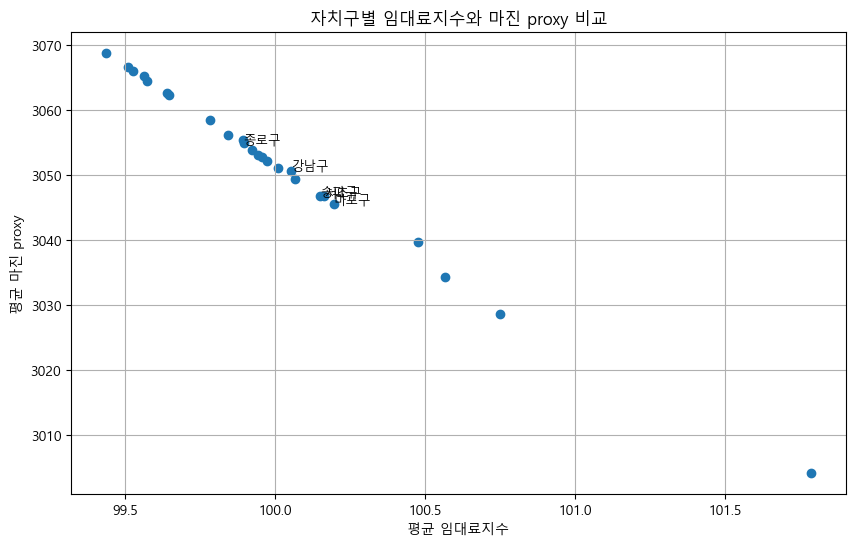

In [21]:
import matplotlib.pyplot as plt
# 한글 깨짐 방지 - Windows 기준
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(10, 6))

plt.scatter(
    gu_margin_summary["avg_rent_index"],
    gu_margin_summary["avg_margin_proxy"]
)

for _, row in gu_margin_summary.iterrows():
    if row["gu"] in ["강남구", "서초구", "송파구", "마포구", "종로구"]:
        plt.text(
            row["avg_rent_index"],
            row["avg_margin_proxy"],
            row["gu"],
            fontsize=9
        )

plt.xlabel("평균 임대료지수")
plt.ylabel("평균 마진 proxy")
plt.title("자치구별 임대료지수와 마진 proxy 비교")
plt.grid(True)
plt.show()

# 14. 시각화2-마진 proxy 상위 자치구

상위 자치구는 업종 평균 매출 대비 임대료 부담이 상대적으로 낮은 지역이다.<br>
따라서 창업 입지 후보를 선별할 때 우선 검토 지역으로 활용할 수 있다.

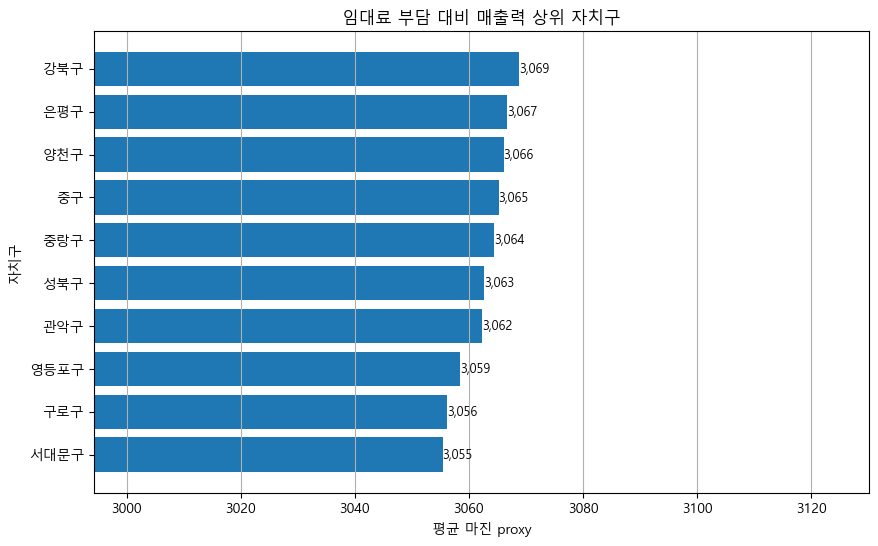

In [25]:
top_margin_gu = gu_margin_summary.head(10).copy()

# 보기 좋게 낮은 값부터 높은 값 순서로 정렬
top_margin_gu = top_margin_gu.sort_values("avg_margin_proxy")

plt.figure(figsize=(10, 6))

plt.barh(
    top_margin_gu["gu"],
    top_margin_gu["avg_margin_proxy"]
)

plt.xlabel("평균 마진 proxy")
plt.ylabel("자치구")
plt.title("임대료 부담 대비 매출력 상위 자치구")

# x축 범위를 좁혀서 차이가 잘 보이게 설정
xmin = top_margin_gu["avg_margin_proxy"].min() * 0.98
xmax = top_margin_gu["avg_margin_proxy"].max() * 1.02
plt.xlim(xmin, xmax)

# 막대 끝에 값 표시
for i, value in enumerate(top_margin_gu["avg_margin_proxy"]):
    plt.text(
        value,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x")
plt.show()

# 15. 시각화3-정책 후보 자치구

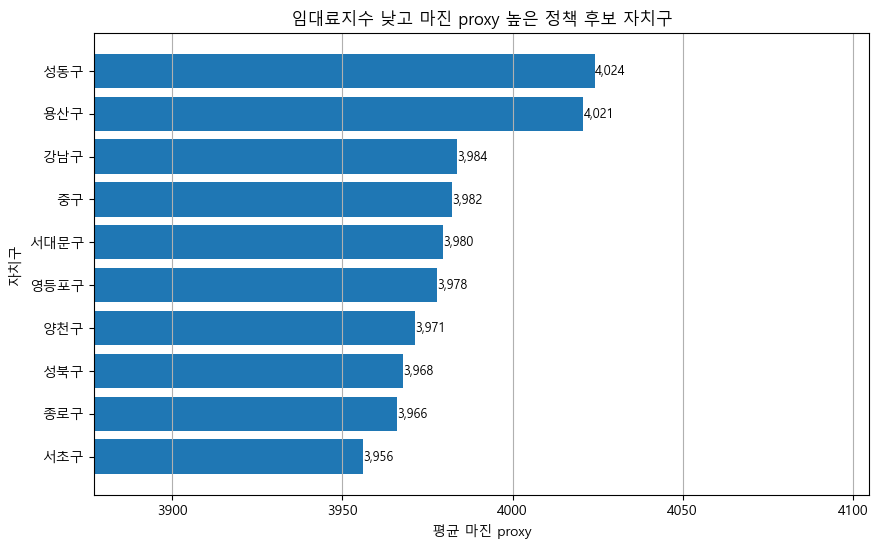

In [26]:
top_policy_gu = policy_gu_summary.head(10).copy()

# 보기 좋게 낮은 값부터 높은 값 순서로 정렬
top_policy_gu = top_policy_gu.sort_values("avg_margin_proxy")

plt.figure(figsize=(10, 6))

plt.barh(
    top_policy_gu["gu"],
    top_policy_gu["avg_margin_proxy"]
)

plt.xlabel("평균 마진 proxy")
plt.ylabel("자치구")
plt.title("임대료지수 낮고 마진 proxy 높은 정책 후보 자치구")

# x축 범위를 좁혀서 차이가 잘 보이게 설정
xmin = top_policy_gu["avg_margin_proxy"].min() * 0.98
xmax = top_policy_gu["avg_margin_proxy"].max() * 1.02
plt.xlim(xmin, xmax)

# 막대 끝에 값 표시
for i, value in enumerate(top_policy_gu["avg_margin_proxy"]):
    plt.text(
        value,
        i,
        f"{value:,.0f}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x")
plt.show()

# 16. 결과 파일 저장하기

`team1_margin_proxy_detail.csv`<br>
→ 자치구·분기·업종별 마진 proxy 상세 데이터

`team1_margin_proxy_gu_summary.csv`<br>
→ 자치구별 평균 마진 proxy 요약

`team1_policy_candidate_detail.csv`<br>
→ 임대료지수 낮고 마진 proxy 높은 후보 상세 데이터

`team1_policy_candidate_gu_summary.csv`<br>
→ 보고서에 넣기 좋은 정책 후보 자치구 요약표

In [24]:
margin_df.to_csv(
    "team1_margin_proxy_detail.csv",
    index=False,
    encoding="utf-8-sig"
)

gu_margin_summary.to_csv(
    "team1_margin_proxy_gu_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

policy_candidate.to_csv(
    "team1_policy_candidate_detail.csv",
    index=False,
    encoding="utf-8-sig"
)

policy_gu_summary.to_csv(
    "team1_policy_candidate_gu_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

부동산·임대료 데이터는 단독으로 창업 입지의 수익성을 판단하기 어렵다. 따라서 본 분석에서는 업종별 평균 가맹점 매출 데이터를 결합하여 임대료 부담 대비 매출력을 나타내는 마진 proxy 지표를 생성하였다.

마진 proxy는 업종별 평균 가맹점 매출을 자치구·분기별 임대가격지수로 나눈 값으로 정의하였다. 이 값이 높을수록 임대료 부담 대비 매출력이 높은 지역으로 해석할 수 있다.

분석 결과, 단순히 임대료가 낮은 지역이 아니라 임대료지수와 매출력을 함께 고려했을 때 창업 입지로서 효율성이 높은 자치구를 선별할 수 있었다. 특히 임대료지수가 중앙값 이하이면서 마진 proxy가 상위 분위에 속하는 자치구·업종 조합을 정책 제언 후보로 선정하였다.

# 그래프 결과 분석
### 13번 그래프: 자치구별 임대료지수와 마진 proxy 비교

13번 그래프는 x축이 평균 임대료지수, y축이 평균 마진 proxy

이 그래프를 보면 임대료지수가 낮을수록 마진 proxy가 높게 나타나는 경향이 있다. 즉, 같은 업종 평균 매출을 가정했을 때 임대료 부담이 낮은 지역일수록 임대료 대비 매출 효율이 좋아지는 구조임.

### 14번 그래프: 마진 proxy 상위 자치구

14번 그래프는 임대료 부담 대비 매출력이 좋은 자치구 상위 10개를 보여줌.

결과를 보면 상위권은 대체로 다음과 같음.

- 강북구<br>
- 은평구<br>
- 양천구<br>
- 중구<br>
- 중랑구<br>
- 성북구<br>
- 관악구<br>
- 영등포구<br>
- 구로구<br>
- 서대문구<br>

이 결과는 “매출이 무조건 높은 지역”이라기보다, 임대료지수 대비 업종 평균 매출 효율이 좋은 지역으로 해석해야 함. 그래서 창업 입지 평가에서는 강남·서초처럼 유명 상권만 보는 게 아니라, 상대적으로 임대료 부담이 낮은 자치구도 후보로 볼 수 있다는 근거가 됌.

### 15번 그래프: 정책 후보 자치구

15번 그래프는 임대료지수가 기준 이하이고, 마진 proxy가 높은 후보 자치구를 보여줌

결과 파일 기준으로 정책 후보 상위권에는 다음 지역들이 들어가 있음.

- 성동구
- 용산구
- 강남구
- 중구
- 서대문구
- 영등포구
- 양천구
- 성북구
- 종로구
- 서초구

여기서 중요한 점은, 15번은 단순히 자치구 전체 평균만 보는 게 아니라 자치구·분기·업종 조합 중 조건을 만족한 경우를 뽑은 거임. 그래서 14번 상위 자치구와 15번 정책 후보 자치구가 완전히 같지는 않음. (기준이 다르기 때문)

본 분석에서 마진 proxy는 실제 순이익을 의미하지 않는다. 다만 임대료 수준을 고려했을 때 매출력이 어느 정도 효율적인지를 비교하기 위한 대리 지표로 사용하였다. 값이 높을수록 임대료 부담 대비 매출 효율이 상대적으로 높다고 해석할 수 있다.

분석 결과, 단순히 거래 규모가 큰 지역이 항상 효율적인 입지는 아니었다. 강남구와 같이 상업 거래가 활발하고 평균 거래금액이 높은 지역도 임대료 부담을 함께 고려하면 마진 proxy 순위가 상대적으로 낮아질 수 있다. 반대로 강북구, 은평구, 양천구 등은 임대료지수가 상대적으로 낮아 임대료 대비 매출 효율이 높게 나타났다.

임대료지수가 일정 기준 이하이고 마진 proxy가 높은 자치구는 창업 부담이 상대적으로 낮은 정책 지원 후보 지역으로 활용할 수 있다.